# MONEY LAUNDERING
Money laundering is the process of hiding the origins of illegally obtained money, typically by means of transfers or transactions that make the money appear to be from a legitimate source.

The process usually happens in three stages:
1) Placement: The illegal money is introduced into the financial system, often through deposits or purchasing assets.
2) Layering: The money is moved around or disguised in a series of complex transactions, like wiring funds, buying and selling assets, or transferring money between accounts to make tracing difficult.
3) Integration: Finally, the "cleaned" money is reintegrated into the economy, and the person can use it freely, as if it were obtained legally.


###  About the dataset
The dataset 'HI-Small_Trans' contains features such as 'Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1','Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering'.
Here the independent features are 'Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1','Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format' depending on which we have to predict our target variable 'Is Laundering'


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv(r"C:\Users\sidsr\OneDrive\Desktop\new_csv\HI-Small_Trans.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [404]:
df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering'],
      dtype='object')

In [405]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering
count,5078345.00,5078345.00,5078345.00,5078345.00,5078345.00
mean,45730.57,65744.56,5988726.07,4509273.37,0.00
std,81765.62,84092.99,1037183108.89,869772830.92,0.03
min,1.00,1.00,0.00,0.00,0.00
25%,119.00,4259.00,183.37,184.48,0.00
50%,9679.00,21568.00,1411.01,1414.54,0.00
75%,28628.00,122332.00,12346.27,12297.84,0.00
max,356303.00,356294.00,1046302363293.48,1046302363293.48,1.00


In [406]:
df.isna().sum()

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64

In [407]:
column_value_counts = {}
for column in df.columns:
    if df[column].dtype=='object':
        column_value_counts[column] = df[column].value_counts()

for column, value_counts in column_value_counts.items():
    print(f"Value counts for column '{column}':\n{value_counts}\n")
    print(" ")

Value counts for column 'Timestamp':
Timestamp
2022/09/01 00:04    11193
2022/09/01 00:26    11025
2022/09/01 00:17    11018
2022/09/01 00:14    11003
2022/09/01 00:29    10998
                    ...  
2022/09/12 15:41        1
2022/09/12 08:51        1
2022/09/11 00:24        1
2022/09/11 11:36        1
2022/09/11 18:15        1
Name: count, Length: 15018, dtype: int64

 
Value counts for column 'Account':
Account
100428660    168672
1004286A8    103018
100428978     20497
1004286F0     18663
100428780     17264
              ...  
806198930         1
806197550         1
80127BE50         1
8061935F0         1
8148A8671         1
Name: count, Length: 496995, dtype: int64

 
Value counts for column 'Account.1':
Account.1
100428660    1084
1004286A8     653
80F47A310     159
100428978     150
8018859B0     144
             ... 
80B14E9D0       1
80B159D00       1
812577710       1
812569750       1
80F91C540       1
Name: count, Length: 420636, dtype: int64

 
Value counts for column '

In [408]:
df.columns

Index(['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1',
       'Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering'],
      dtype='object')

In [15]:
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


# UNIVARIATE ANALYSIS


Counts of Laundering vs Legitimate Transactions:
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

Percentage Distribution:
Is Laundering
0    99.898057
1     0.101943
Name: count, dtype: float64


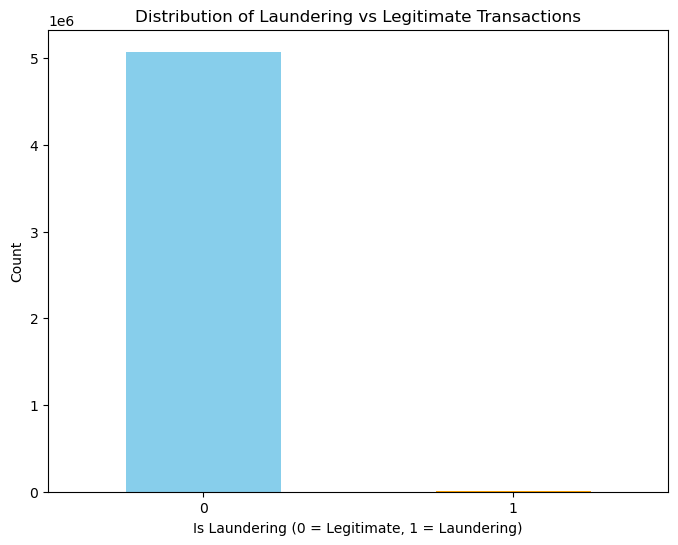

In [32]:
laundering_counts = df['Is Laundering'].value_counts()
laundering_percentage = (laundering_counts / len(df)) * 100

print("Counts of Laundering vs Legitimate Transactions:")
print(laundering_counts)
print("\nPercentage Distribution:")
print(laundering_percentage)

# Plot the distribution
plt.figure(figsize=(8, 6))
laundering_counts.plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Distribution of Laundering vs Legitimate Transactions")
plt.xlabel("Is Laundering (0 = Legitimate, 1 = Laundering)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


#### The Dataset is highly imbalanced, with the 'Is Laundering' column being extremely skewed. This is very common in datasets related to fraudulent activities, where actual fraudulent activities are rare. Resampling has to be done.

In [33]:
laundering_transactions = df[df['Is Laundering'] == 1]
legitimate_transactions = df[df['Is Laundering'] == 0]

def calculate_stats(column, transaction_type):
    return {
        'Mean': column.mean(),
        'Median': column.median(),
        'Min': column.min(),
        'Max': column.max(),
        'Range': column.max() - column.min(),
        'Skewness': column.skew(),
    }

amount_received_stats_laundering = calculate_stats(laundering_transactions['Amount Received'], "Laundering")
amount_received_stats_legitimate = calculate_stats(legitimate_transactions['Amount Received'], "Legitimate")

amount_paid_stats_laundering = calculate_stats(laundering_transactions['Amount Paid'], "Laundering")
amount_paid_stats_legitimate = calculate_stats(legitimate_transactions['Amount Paid'], "Legitimate")

print("Amount Received (Laundering):", amount_received_stats_laundering)
print("Amount Received (Legitimate):", amount_received_stats_legitimate)

print("\nAmount Paid (Laundering):", amount_paid_stats_laundering)
print("Amount Paid (Legitimate):", amount_paid_stats_legitimate)



Amount Received (Laundering): {'Mean': 36135310.41281265, 'Median': 8667.21, 'Min': 0.003227, 'Max': 84853144179.58, 'Range': 84853144179.57678, 'Skewness': 49.44634089358389}
Amount Received (Legitimate): {'Mean': 5957962.478734538, 'Median': 1407.51, 'Min': 1e-06, 'Max': 1046302363293.48, 'Range': 1046302363293.48, 'Skewness': 651.0063488280698}

Amount Paid (Laundering): {'Mean': 36135310.41281265, 'Median': 8667.21, 'Min': 0.003227, 'Max': 84853144179.58, 'Range': 84853144179.57678, 'Skewness': 49.44634089358389}
Amount Paid (Legitimate): {'Mean': 4477000.043896748, 'Median': 1410.99, 'Min': 1e-06, 'Max': 1046302363293.48, 'Range': 1046302363293.48, 'Skewness': 862.1026523455029}


For both the columns, 'Amount Paid' and 'Amount Recieved' the mean>median , which explains the presence of some outliers on the extreme side of both the features; dragging some of the values to higher ranges. Also, the range between min and max values of both these columns are also huge, which tells that there is a lot of variation in the transactions happening. 
We also find that there are many transactions in case of laundering, where the values of both the 'Amount Paid' and 'Amount Recieved' is same which tells that laundering transactions tend to involve transferring nearly equivalent amounts between accounts (e.g., layering money).

{'whiskers': [<matplotlib.lines.Line2D at 0x2b38ee597d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2b3b43901d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b3b43c5790>],
 'medians': [<matplotlib.lines.Line2D at 0x2b3b4390d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b39c7d9650>],
 'means': []}

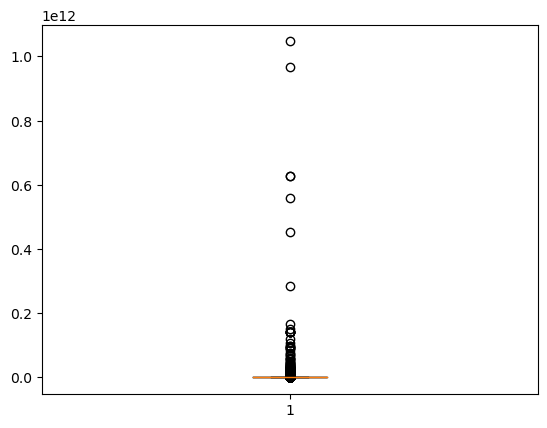

In [34]:
plt.boxplot(df['Amount Paid'])

{'whiskers': [<matplotlib.lines.Line2D at 0x2b38d9b1a10>,
 'caps': [<matplotlib.lines.Line2D at 0x2b3c6cbdf10>,
 'boxes': [<matplotlib.lines.Line2D at 0x2b3bffca390>],
 'medians': [<matplotlib.lines.Line2D at 0x2b3a96a4790>],
 'fliers': [<matplotlib.lines.Line2D at 0x2b3b43b94d0>],
 'means': []}

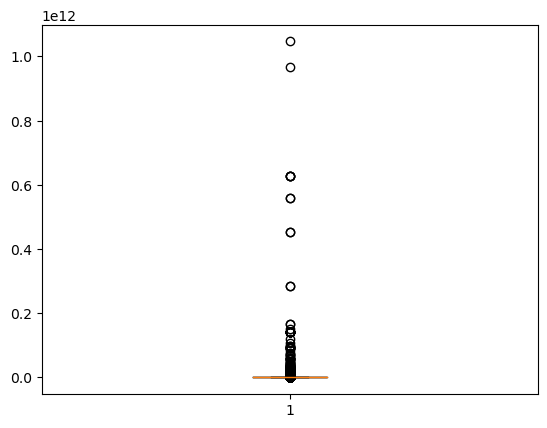

In [35]:
plt.boxplot(df['Amount Received'])

There are alot of outliers present in both these columns but since the goal is to detect rare or extreme events,like laundering transactions, you must retain outliers as they might be key indicators of illicit behavior. Lundering Transactions might involve inheritently high amounts of unsual transactions. Removing the outliers might not be the correct way to deal with.

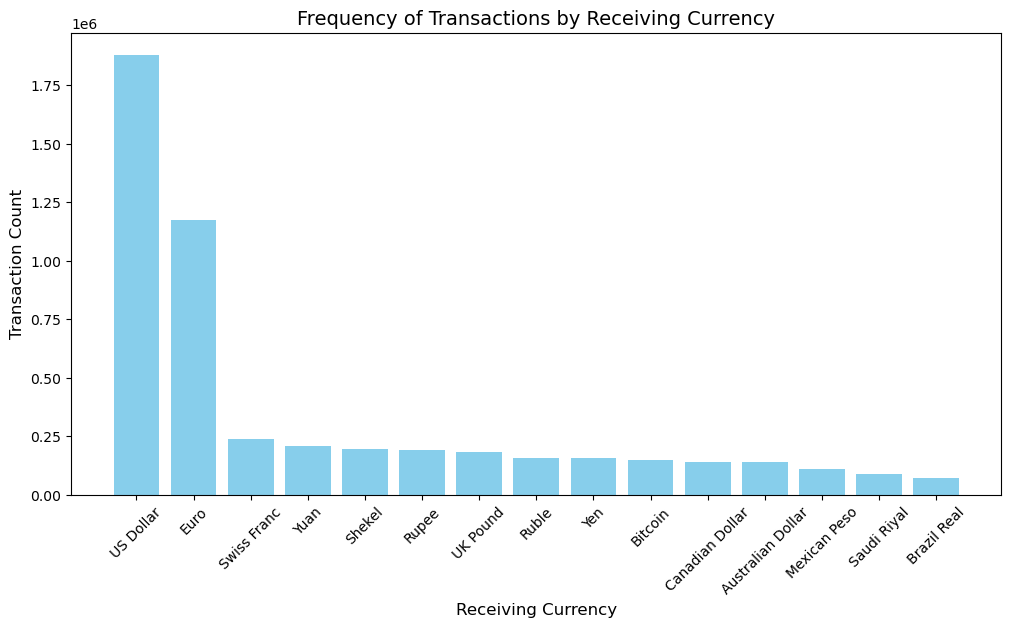

In [36]:
import matplotlib.pyplot as plt


receiving_currency_counts = df['Receiving Currency'].value_counts()

payment_currency_counts = df['Payment Currency'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(receiving_currency_counts.index, receiving_currency_counts.values, color='skyblue')
plt.title('Frequency of Transactions by Receiving Currency', fontsize=14)
plt.xlabel('Receiving Currency', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

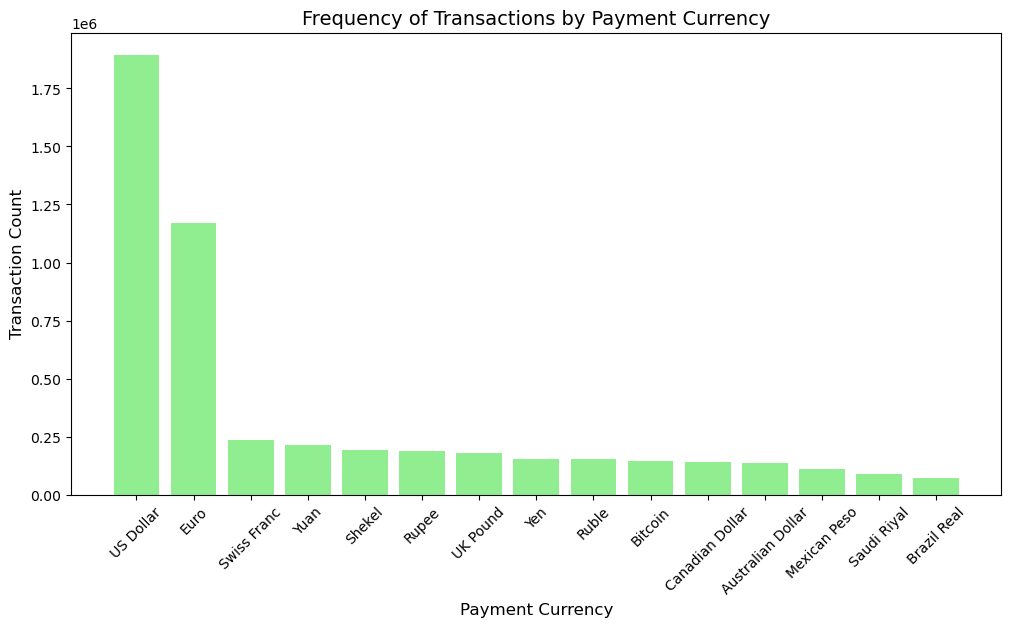

In [20]:
plt.figure(figsize=(12, 6))
plt.bar(payment_currency_counts.index, payment_currency_counts.values, color='lightgreen')
plt.title('Frequency of Transactions by Payment Currency', fontsize=14)
plt.xlabel('Payment Currency', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

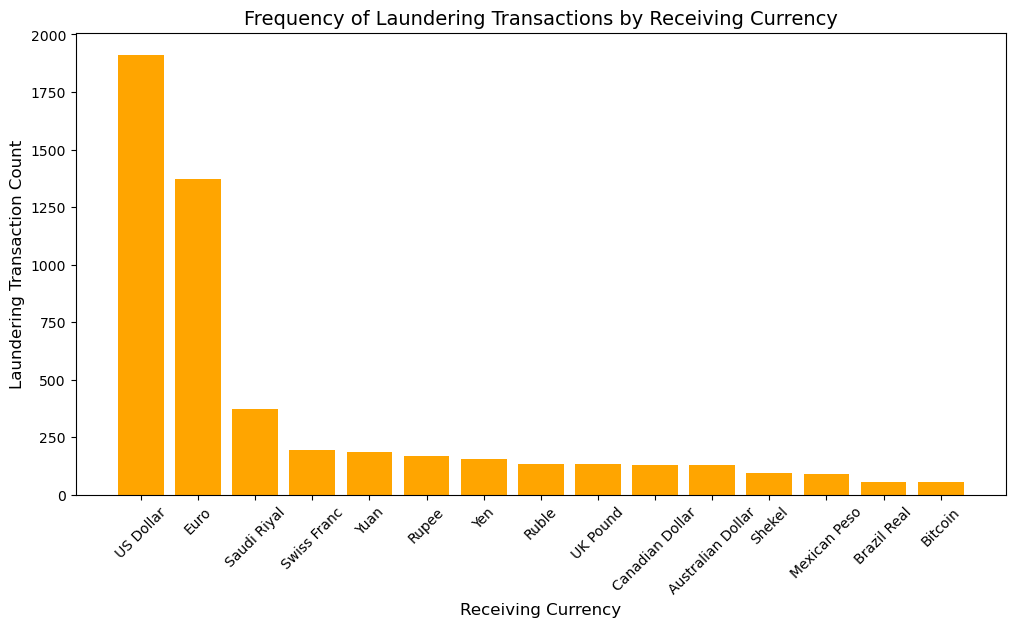

In [21]:
laundering_receiving_currency = df[df['Is Laundering'] == 1]['Receiving Currency'].value_counts()

laundering_payment_currency = df[df['Is Laundering'] == 1]['Payment Currency'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(laundering_receiving_currency.index, laundering_receiving_currency.values, color='orange')
plt.title('Frequency of Laundering Transactions by Receiving Currency', fontsize=14)
plt.xlabel('Receiving Currency', fontsize=12)
plt.ylabel('Laundering Transaction Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

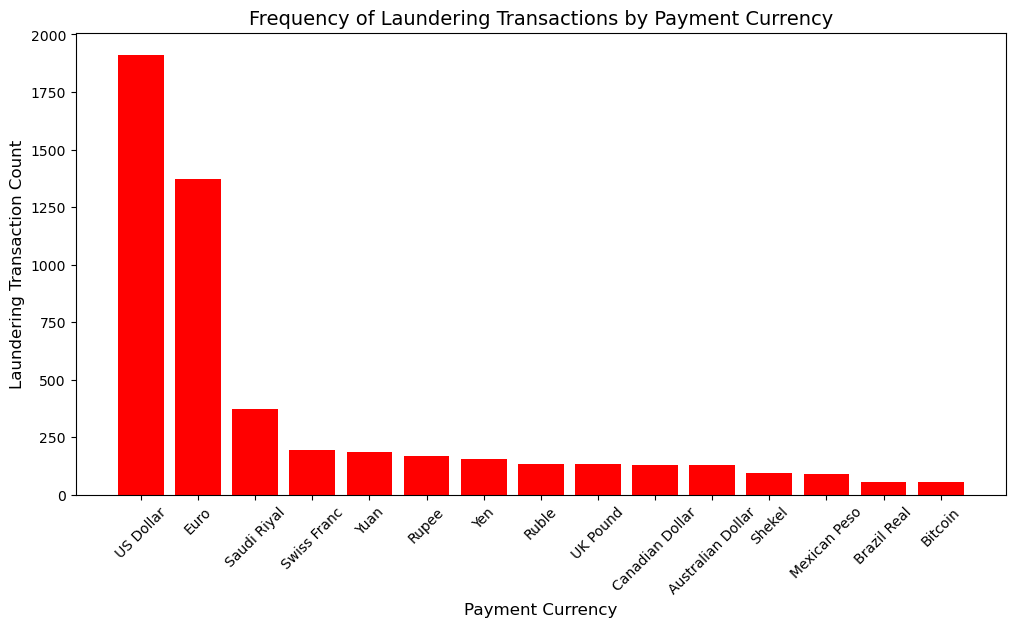

In [22]:
plt.figure(figsize=(12, 6))
plt.bar(laundering_payment_currency.index, laundering_payment_currency.values, color='red')
plt.title('Frequency of Laundering Transactions by Payment Currency', fontsize=14)
plt.xlabel('Payment Currency', fontsize=12)
plt.ylabel('Laundering Transaction Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

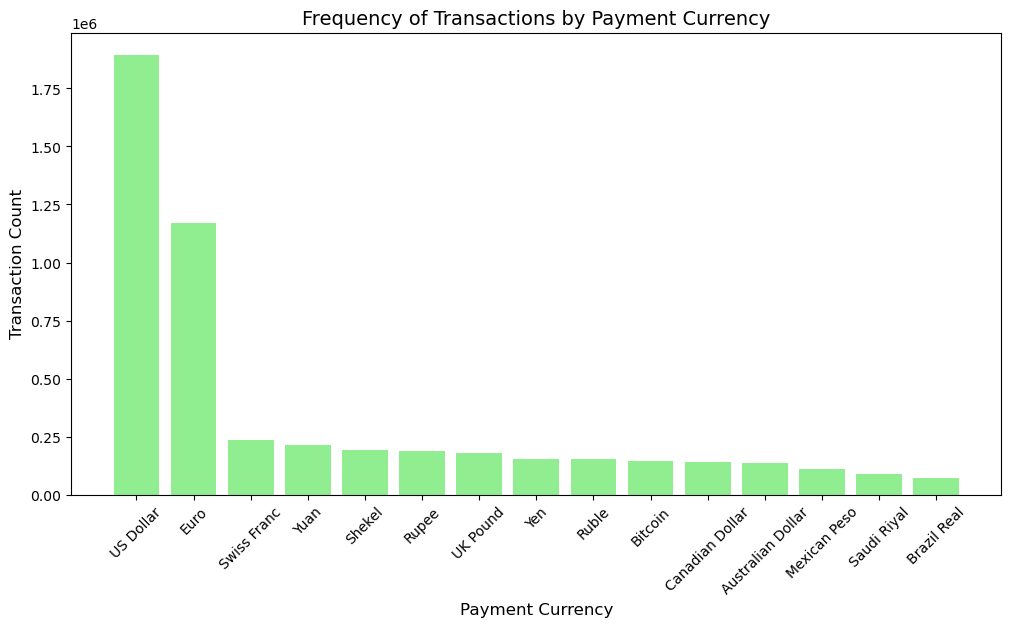

In [24]:
plt.figure(figsize=(12, 6))
plt.bar(payment_currency_counts.index, payment_currency_counts.values, color='lightgreen')
plt.title('Frequency of Transactions by Payment Currency', fontsize=14)
plt.xlabel('Payment Currency', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.xticks(rotation=45)
plt.show()

1)The lists of currencies used for receiving and payment are nearly identical, which suggests no specific bias toward certain     currencies for sending or receiving funds. 

2)Laundering transactions show a similar distribution across currencies, with US Dollar and Euro still leading. This suggests 
  that even illicit transactions prefer these widely accepted currencies for easier integration into financial systems.
  
3)The frequency of laundering transactions in certain currencies (e.g., Saudi Riyal, Yuan, Swiss Franc) might indicate regions 
  where laundering operations are more active, or jurisdictions with financial systems exploited for such activities.
  
4)The presence of Bitcoin in both legitimate and laundering transactions highlights its role as an alternative currency, often 
  associated with anonymity in financial dealings.

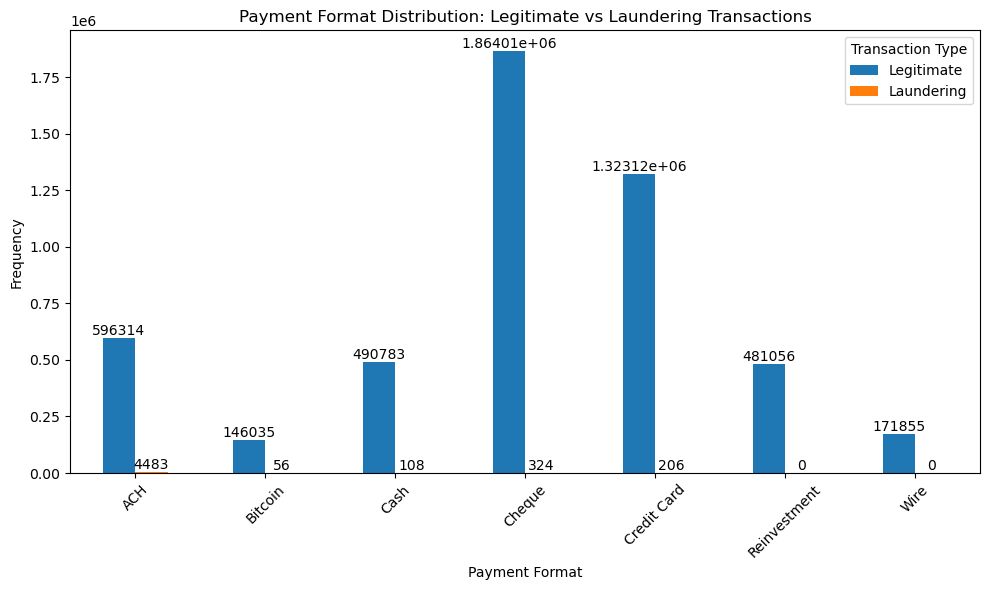

In [11]:
import matplotlib.pyplot as plt

# Frequency of Payment Format for laundering vs legitimate
payment_format_legit = df[df['Is Laundering'] == 0]['Payment Format'].value_counts()
payment_format_laundering = df[df['Is Laundering'] == 1]['Payment Format'].value_counts()

payment_format_data = pd.DataFrame({
    'Legitimate': payment_format_legit,
    'Laundering': payment_format_laundering
}).fillna(0)

# Bar Plot
ax = payment_format_data.plot(kind='bar', figsize=(10, 6))
plt.title('Payment Format Distribution: Legitimate vs Laundering Transactions')
plt.ylabel('Frequency')
plt.xlabel('Payment Format')
plt.xticks(rotation=45)
plt.legend(title='Transaction Type')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10)

plt.tight_layout()
plt.show()


In [22]:
df.tail(5)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
5078340,2022-09-18 10:02:00,9371,8043A0FB0,16163,802F78670,3749.14,US Dollar,3749.14,US Dollar,ACH,1
5078341,2022-09-18 11:18:00,9371,8043A0FB0,9371,8043A0FB0,1785.27,Euro,2091.95,US Dollar,ACH,0
5078342,2022-09-18 11:18:00,9371,8043A0FB0,13858,8095526B0,1785.27,Euro,1785.27,Euro,ACH,1
5078343,2022-09-18 12:58:00,9371,8043A0FB0,1124,8026687E0,2154.54,US Dollar,2154.54,US Dollar,ACH,1
5078344,2022-09-18 16:18:00,9371,8043A0FB0,4503,809320130,5448.55,US Dollar,5448.55,US Dollar,ACH,1


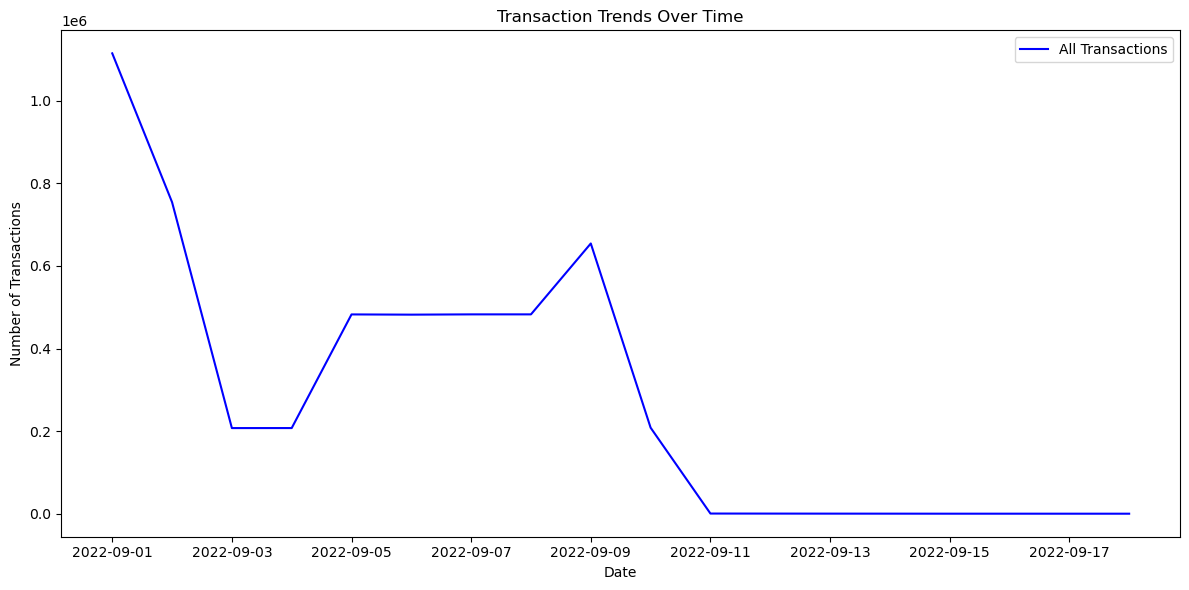

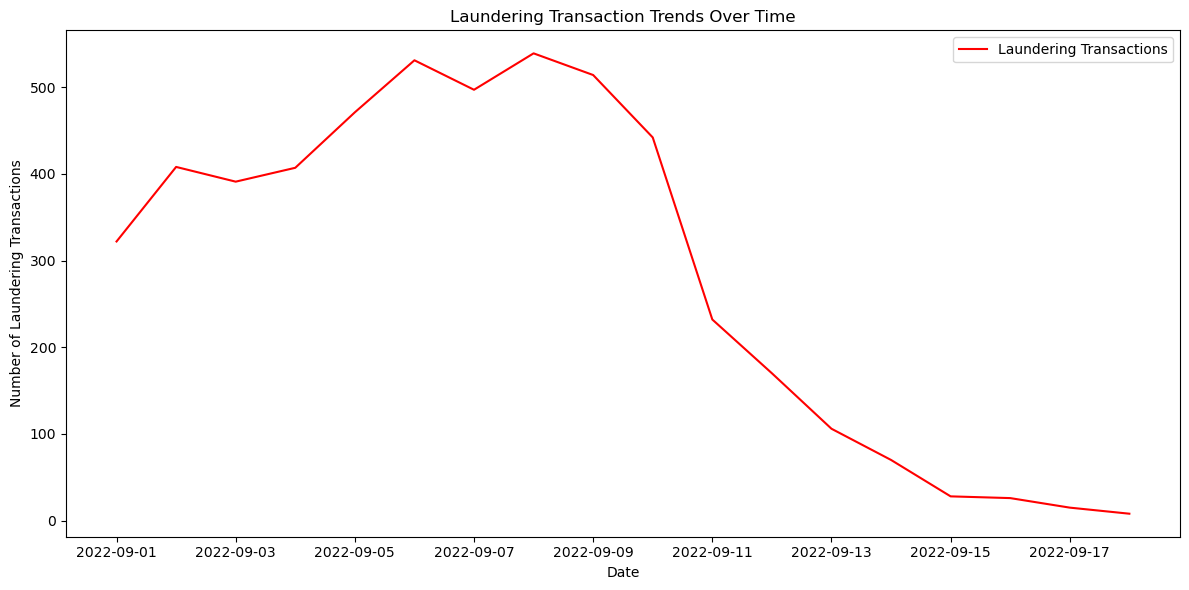

In [7]:

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df = df.sort_values(by='Timestamp')

df.reset_index(drop=True, inplace=True)

# Count of transactions per day
transactions_per_day = df.groupby(df['Timestamp'].dt.date).size()

# Line chart
plt.figure(figsize=(12, 6))
transactions_per_day.plot(kind='line', color='blue', label='All Transactions')
plt.title('Transaction Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend()
plt.tight_layout()
plt.show()

# Peaks in laundering transactions
laundering_transactions_per_day = df[df['Is Laundering'] == 1].groupby(df['Timestamp'].dt.date).size()

plt.figure(figsize=(12, 6))
laundering_transactions_per_day.plot(kind='line', color='red', label='Laundering Transactions')
plt.title('Laundering Transaction Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Laundering Transactions')
plt.legend()
plt.tight_layout()
plt.show()


### Transaction Trends Over Time:
1) Initial Decline (2022-09-01 to 2022-09-03): A drop in the overall transaction volume could indicate a slow period or low activity, possibly due to non-operational days (weekends, holidays) or fewer transactions in general. The straight line suggests minimal fluctuation in transaction volume during this period.
2) Subsequent Increase (2022-09-03 to 2022-09-05): A sudden rise in transactions could signify an event or specific action that caused a spike in transaction activity, such as an important business or financial event. This could be a period of increased buying, sales, or significant financial movement.
3) Stable Period (2022-09-05 to 2022-09-07): After the spike, the transaction trend remained steady, indicating a period of consistent activity. The stable value might suggest normal operations without major changes or disruptions.
4) Second Increase (2022-09-08 to 2022-09-09): A sharp increase in transactions from 0.4 to 0.65 could again signify another event or surge in activity, potentially related to financial or market factors. The increase is more abrupt compared to the earlier increase, which could point to significant financial events.
5) Sudden Drop (2022-09-09 to 2022-09-11): The sharp drop to 0 could be due to a significant disruption or holiday period where transactions were significantly reduced or halted. This may also signal a non-operational phase or unexpected pause in the activity.
6) Stability After Drop (2022-09-11 to 2022-09-17): The long straight line suggests consistent but low-volume transactions. This could indicate a period of low activity, with transactions stabilizing at lower levels after the drop.


### Laundering Transaction Trends Over Time
1) Early Increase (2022-09-01 to 2022-09-03): The initial increase in laundering transactions could indicate a slow buildup of illicit activity, potentially ramping up as more transactions are conducted to obscure illegal funds.
2) Steady Trend (2022-09-03 to 2022-09-04): A steady line suggests that laundering activities during this period were stable, possibly indicating a phase where illegal transactions were proceeding at a constant pace without major fluctuations.
3) Sudden Increase (2022-09-03 to 2022-09-05): This sharp increase might represent a concentrated effort to launder a significant amount of illicit funds, possibly due to a specific event or action taken by the criminals involved.
4) Drop to 450 (2022-09-05 to 2022-09-07): The decrease could reflect a period where laundering activities slowed down, possibly because of an investigation, awareness, or regulatory actions.
5) Second Surge (2022-09-09): A second increase in laundering activities could indicate that efforts to obscure illicit transactions were revived, with criminals attempting to hide funds in another round of activity.
6) Gradual Decline (2022-09-09 to 2022-09-17): The steady decrease in laundering transactions as we approach 2022-09-17 may reflect the aftermath of a period of heightened activity, possibly indicating reduced opportunity for laundering or that the illicit actors have moved to other strategies.

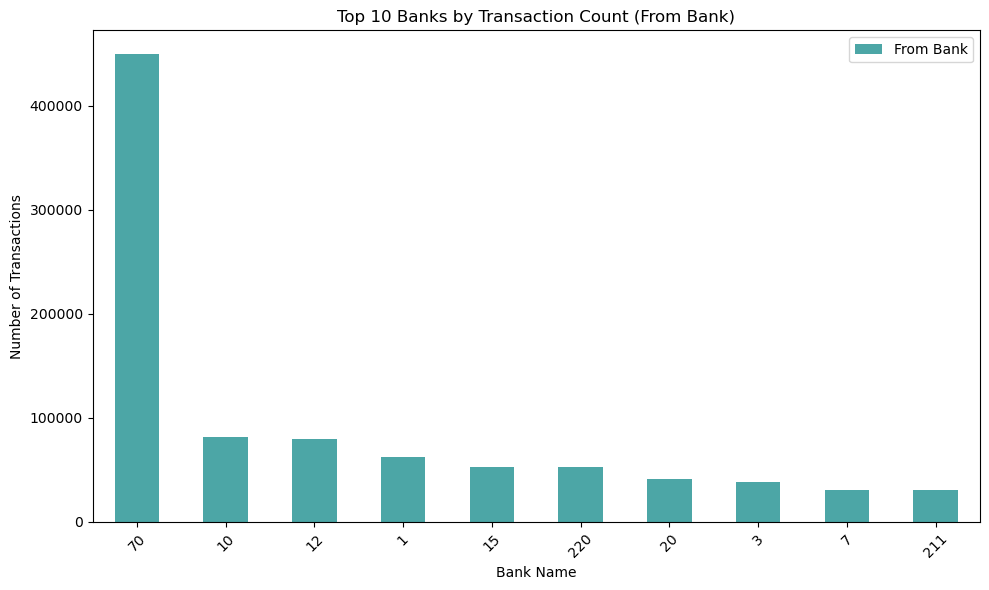

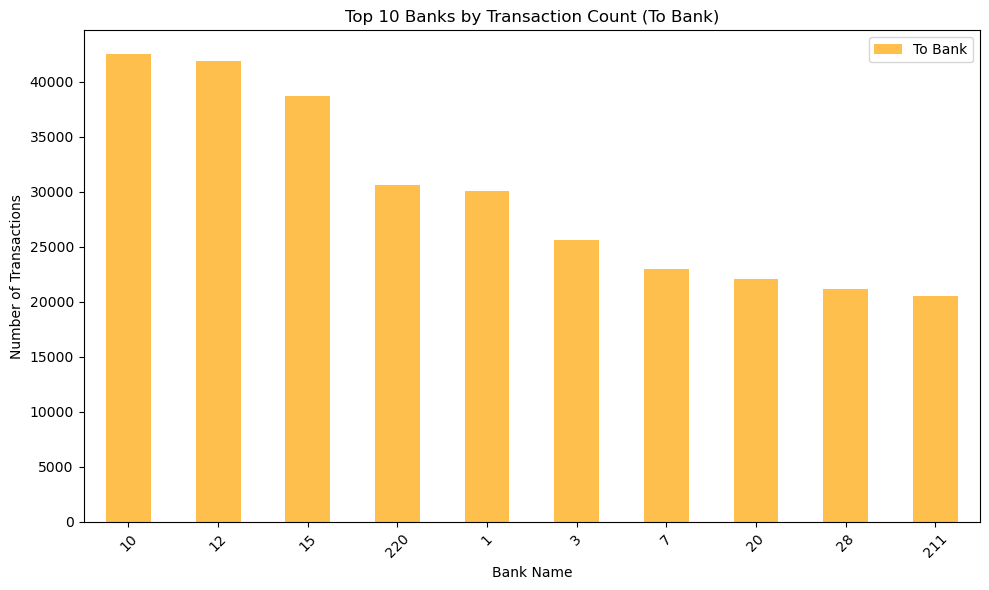

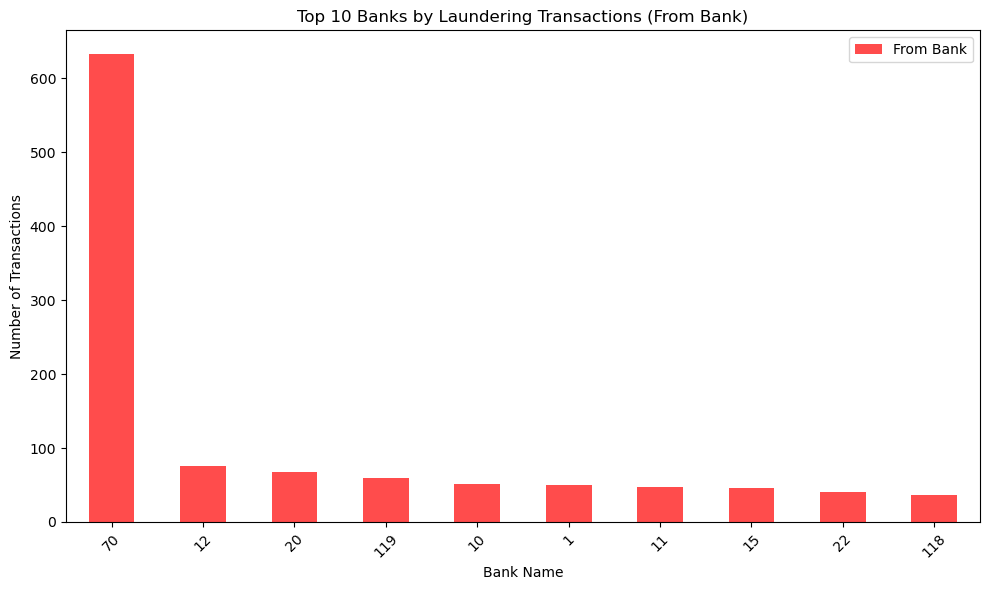

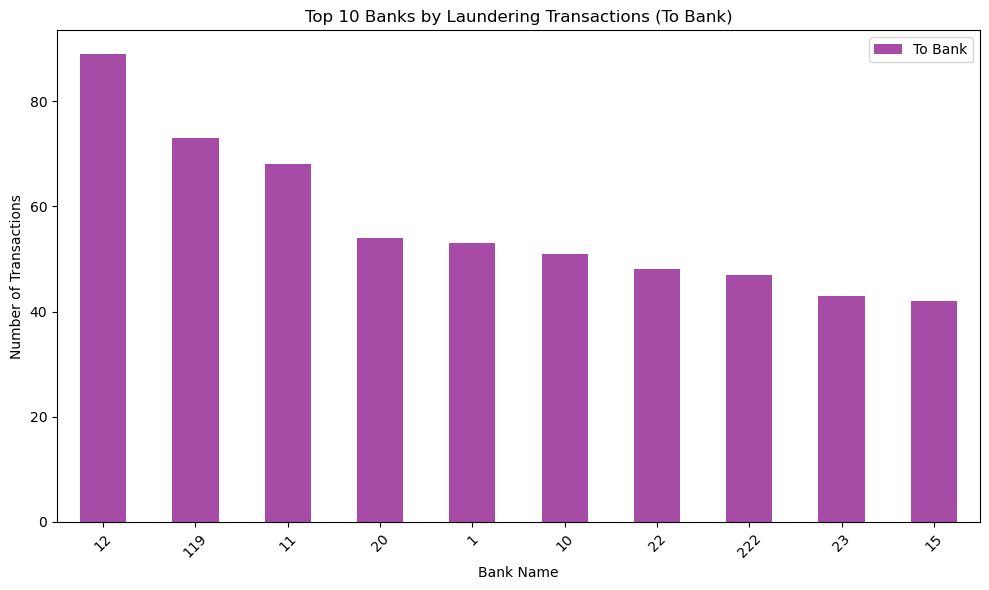

In [10]:

from_bank_counts = df['From Bank'].value_counts().head(10)  # Top 20 banks
to_bank_counts = df['To Bank'].value_counts().head(10)      # Top 20 banks

# Bar plot for From Bank
plt.figure(figsize=(10, 6))
from_bank_counts.plot(kind='bar', color='teal', alpha=0.7, label='From Bank')
plt.title('Top 10 Banks by Transaction Count (From Bank)')
plt.ylabel('Number of Transactions')
plt.xlabel('Bank Name')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Bar plot for To Bank
plt.figure(figsize=(10, 6))
to_bank_counts.plot(kind='bar', color='orange', alpha=0.7, label='To Bank')
plt.title('Top 10 Banks by Transaction Count (To Bank)')
plt.ylabel('Number of Transactions')
plt.xlabel('Bank Name')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Banks involved in laundering transactions
from_bank_laundering = df[df['Is Laundering'] == 1]['From Bank'].value_counts().head(10)
to_bank_laundering = df[df['Is Laundering'] == 1]['To Bank'].value_counts().head(10)

# Bar plot for Laundering Transactions
plt.figure(figsize=(10, 6))
from_bank_laundering.plot(kind='bar', color='red', alpha=0.7, label='From Bank')
plt.title('Top 10 Banks by Laundering Transactions (From Bank)')
plt.ylabel('Number of Transactions')
plt.xlabel('Bank Name')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
to_bank_laundering.plot(kind='bar', color='purple', alpha=0.7, label='To Bank')
plt.title('Top 10 Banks by Laundering Transactions (To Bank)')
plt.ylabel('Number of Transactions')
plt.xlabel('Bank Name')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# Relation between 'From Bank' and 'To Bank'
1) A few banks such as appear to dominate laundering activities, suggesting systemic issues at these institutions. These could include weaker Anti-Money Laundering controls or direct complicity.
2) The differences between "From Bank" and "To Bank" laundering patterns suggest that laundering strategies involve dispersing funds across multiple banks, complicating detection and tracing.
3) Bank 70 (highest laundering "From Bank") and bank 12 (highest laundering "To Bank") should be prioritized for audits or investigations.
4) The disparity in transaction volumes among the banks indicates that laundering activities are concentrated in specific institutions, while most banks operate with low transaction counts and minimal laundering involvement.

So let's further try to investigate these specific banks using a heatmap:


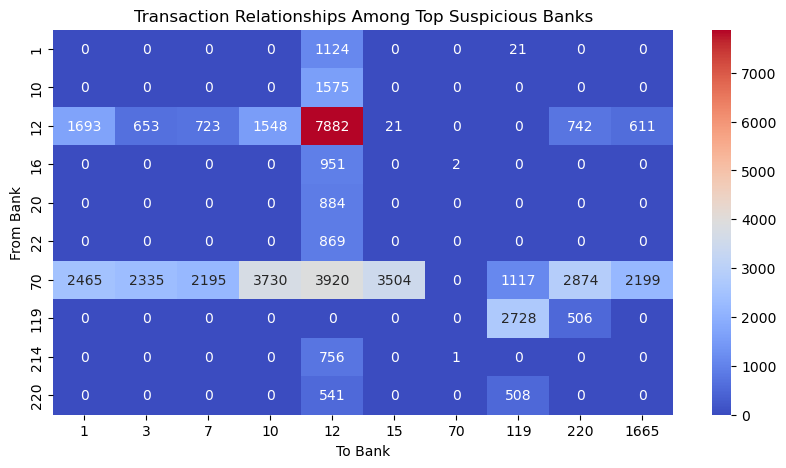

In [22]:

top_from_banks = detailed_analysis.groupby('From Bank')['Transaction Count'].sum().nlargest(10).index
top_to_banks = detailed_analysis.groupby('To Bank')['Transaction Count'].sum().nlargest(10).index

filtered_data = detailed_analysis[
    (detailed_analysis['From Bank'].isin(top_from_banks)) &
    (detailed_analysis['To Bank'].isin(top_to_banks))
]

heatmap_data = filtered_data.pivot(index='From Bank', columns='To Bank', values='Transaction Count')

heatmap_data = heatmap_data.fillna(0)

# heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    data=heatmap_data,
    annot=True, fmt='.0f', cmap='coolwarm', cbar=True
)
plt.title('Transaction Relationships Among Top Suspicious Banks')
plt.xlabel('To Bank')
plt.ylabel('From Bank')
plt.show()


In [38]:
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


### Understanding the Heatmap
1) The consistent involvement of Bank 70 across different counterparties suggests it could be central in a network of suspicious transactions.
2) 'From Bank': 12, 'To Bank': 12 with 7882 transactions suggests a high volume of intra-bank transactions. This could imply internal fund movements or possibly obfuscation attempts.
3) Since Bank 70 is common for initiating the transactions for more than 1 bank, we can say that Bank 70 might act as a hub, funneling transactions to multiple other banks.

# BIVARIATE ANALYSIS

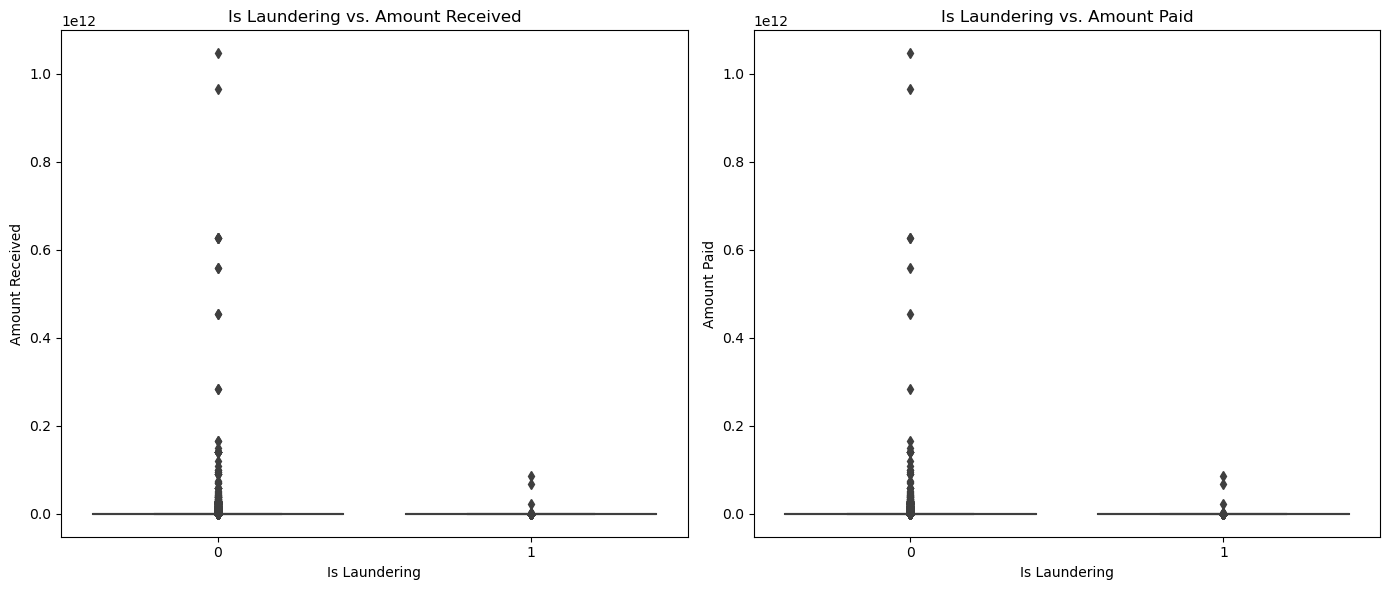

In [6]:
# Is Laundering vs. Amount Received / Amount Paid
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Is Laundering', y='Amount Received')
plt.title('Is Laundering vs. Amount Received')
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Is Laundering', y='Amount Paid')
plt.title('Is Laundering vs. Amount Paid')
plt.tight_layout()
plt.show()

### Is Laundering vs. Amount Received / Amount Paid
1) For 'Not Laundering' Transactions, Most of the transaction amounts are concentrated in the range of 0 to 0.2. This suggests 
   that legitimate transactions are predominantly small in terms of value.
2) For 'Laundering' Transactions, Similarly, the majority of transaction amounts are also concentrated in the range of 0 to 0.2.
   This implies that even laundering transactions tend to mimic smaller, less conspicuous amounts to avoid detection.


### Grouped Bar Chart for Is Laundering vs Receiving Currency / Payment Currency

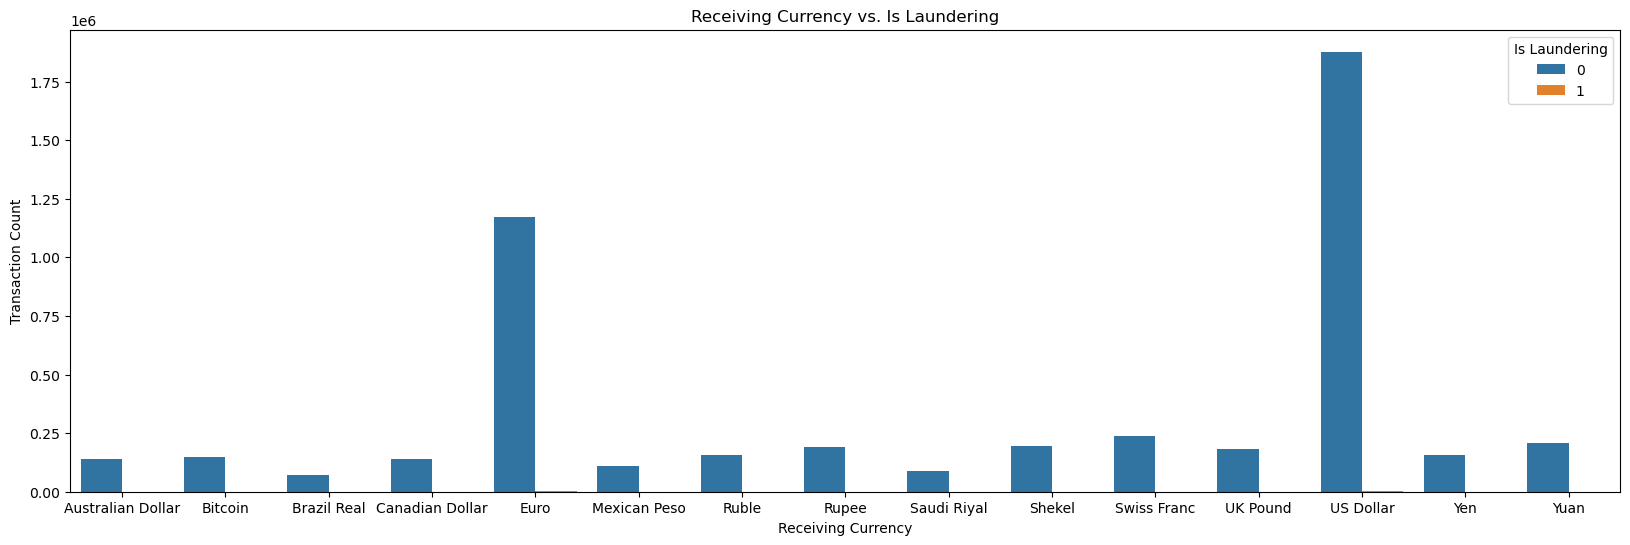

In [30]:

currency_data = df.groupby(['Is Laundering', 'Receiving Currency']).size().reset_index(name='Transaction Count')
plt.figure(figsize=(20, 6))
sns.barplot(data=currency_data, x='Receiving Currency', y='Transaction Count', hue='Is Laundering')
plt.title('Receiving Currency vs. Is Laundering')
plt.show()

### Grouped Bar Chart for Is Laundering vs Payment Format

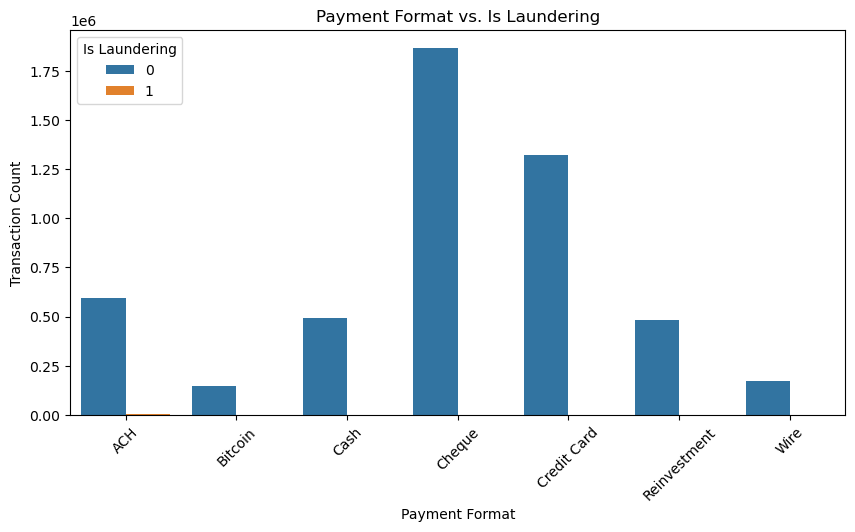

In [35]:

payment_format_data = df.groupby(['Is Laundering', 'Payment Format']).size().reset_index(name='Transaction Count')
plt.figure(figsize=(10, 5))
sns.barplot(data=payment_format_data, x='Payment Format', y='Transaction Count', hue='Is Laundering')
plt.title('Payment Format vs. Is Laundering')
plt.xticks(rotation=45)
plt.show()

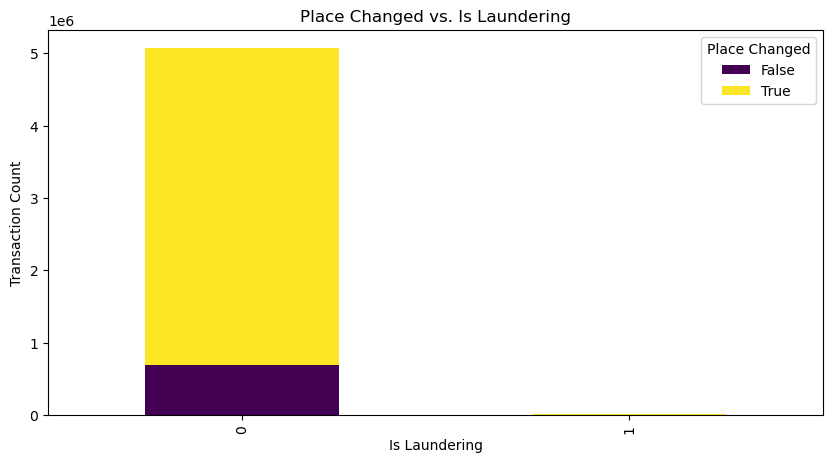

In [40]:

df['Place Changed'] = df['From Bank'] != df['To Bank']
place_changed_data = df.groupby(['Is Laundering', 'Place Changed']).size().unstack(fill_value=0)
place_changed_data.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='viridis')
plt.title('Place Changed vs. Is Laundering')
plt.xlabel('Is Laundering')
plt.ylabel('Transaction Count')
plt.show()

### Stacked Bar Chart for Place Changed vs. Is Laundering
1) For 'Not Laundering' Transactions, The majority of transactions involve a change in place (Place Changed = True), meaning that most legitimate transactions occur between different banks (From Bank ≠ To Bank)
2) For 'Laundering' Transactions, Within this subset, the majority still involve a change in place (Place Changed = True), suggesting that laundering activities also commonly involve transferring funds across different banks, potentially as part of the strategy to obscure the origin or destination of funds.
3) The dominance of Place Changed = True in both laundering and legitimate transactions highlights the importance of monitoring inter-bank transactions for anomalies.


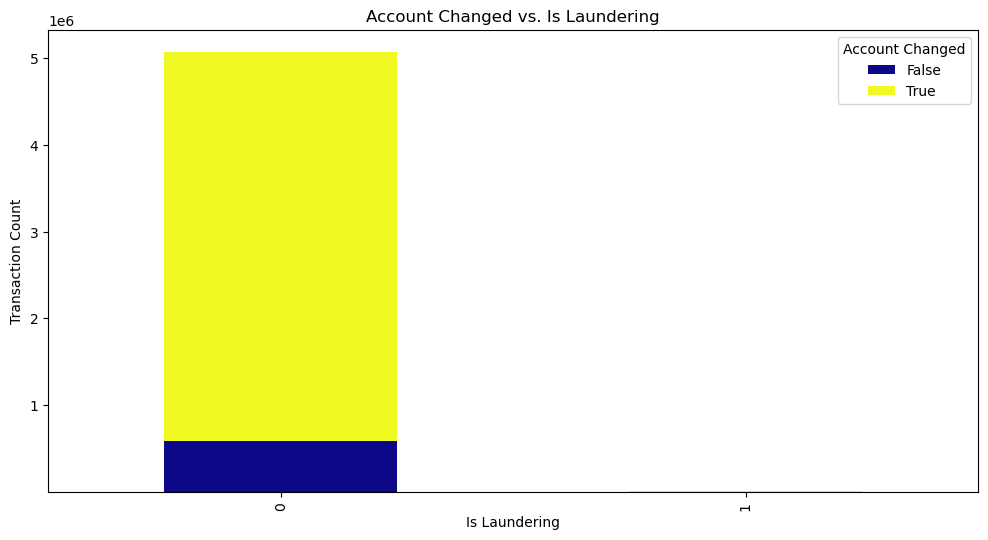

In [41]:
# Stacked Bar Chart for Account Changed vs. Is Laundering
df['Account Changed'] = df['Account'] != df['Account.1']
account_changed_data = df.groupby(['Is Laundering', 'Account Changed']).size().unstack(fill_value=0)
account_changed_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='plasma')
plt.title('Account Changed vs. Is Laundering')
plt.xlabel('Is Laundering')
plt.ylabel('Transaction Count')
plt.show()

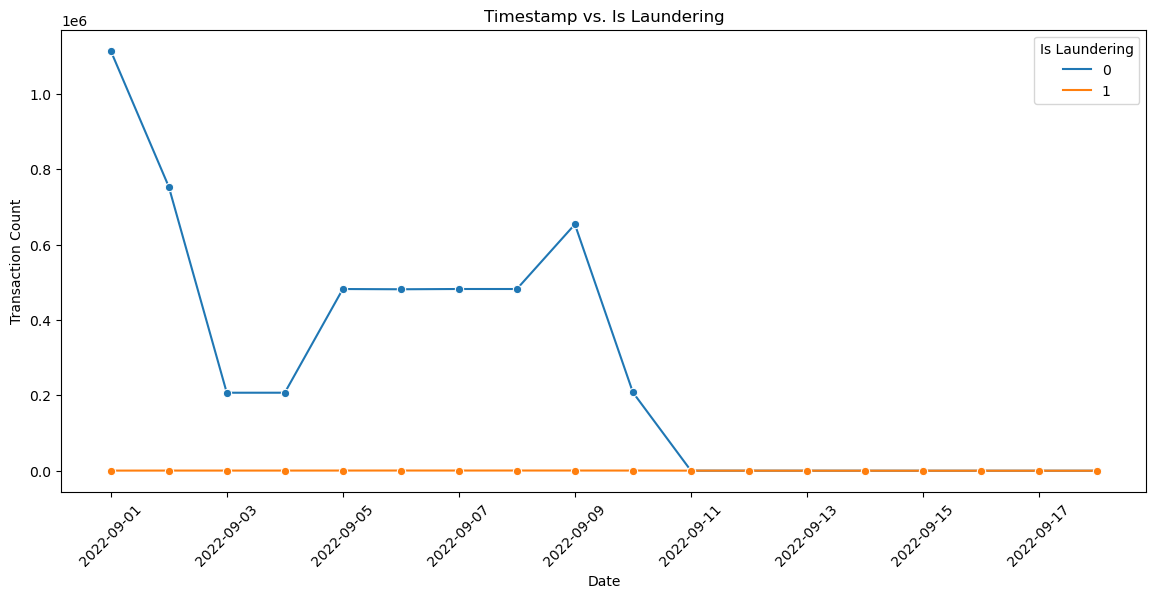

In [42]:
# Time-Series Plot for Timestamp vs. Is Laundering
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
time_series_data = df.groupby([df['Timestamp'].dt.date, 'Is Laundering']).size().reset_index(name='Transaction Count')
plt.figure(figsize=(14, 6))
sns.lineplot(data=time_series_data, x='Timestamp', y='Transaction Count', hue='Is Laundering', marker='o')
plt.title('Timestamp vs. Is Laundering')
plt.xlabel('Date')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.show()

In [253]:
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [87]:
df['Is Laundering'].value_counts()

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64

In [254]:
df[df['Is Laundering']==0]['Payment Format'].value_counts()

Payment Format
Cheque          1864007
Credit Card     1323118
ACH              596314
Cash             490783
Reinvestment     481056
Wire             171855
Bitcoin          146035
Name: count, dtype: int64

# Data Processing

In [43]:
def change(col, zero, one):
    
    for i in range(col.shape[0]):
        if col.values[i]==zero:
            col.values[i]=0
        elif col.values[i]==one:
            col.values[i]=1
        else:
            col.values[i]=2
    return col

Larger records (more columns or high cardinality features) consume more memory. If your dataset has many features, a smaller chunk size may be better.


In [44]:
dfs = []

In [45]:
import numpy as np
count = 0

for df in pd.read_csv(r"C:\Users\sidsr\OneDrive\Desktop\new_csv\HI-Small_Trans.csv", chunksize=1000000):
    df = df[df['Is Laundering'] == 1]
    del df['Timestamp']
    #Feature Engineering
    place_changed = []
    account_changed = []
    
    for i in range(df.shape[0]):
        if df['From Bank'].values[i] == df['To Bank'].values[i]:
            place_changed.append(0)
        else:
            place_changed.append(1)
        
        if df['Account'].values[i] == df['Account.1'].values[i]:
            account_changed.append(0)
        else:
            account_changed.append(1)
    
    place_changed = np.array(place_changed)
    account_changed = np.array(account_changed)
    del df['From Bank']
    del df['To Bank']
    del df['Account']
    del df['Account.1']
    
    df['Place Changed'] = place_changed
    df['Account Changed'] = account_changed
    df['Receiving Currency'] = change(df['Receiving Currency'], 'US Dollar', 'Euro')
    df['Payment Currency'] = change(df['Payment Currency'], 'US Dollar', 'Euro')
    df['Payment Format'] = change(df['Payment Format'], 'Cheque', 'Credit Card')

    dfs.append(df)
    
#     print('part {} done'.format(str(count)))
    count += 1

In [46]:
df_0 = pd.concat(dfs)
del dfs #Deleting the list of processed chunks to free up memory.
limit = df_0.shape[0]
print(limit)
dfs = []

5177


In [47]:
count = 0
current = 0

for df in pd.read_csv(r"C:\Users\sidsr\OneDrive\Desktop\new_csv\HI-Small_Trans.csv", chunksize=1000):
    df = df[df['Is Laundering'] == 0]
    current += df.shape[0]
    
    del df['Timestamp']
#     df['Log Amount Received'] = np.log1p(df['Amount Received'])
    
    place_changed = []
    account_changed = []
    
    for i in range(df.shape[0]):
        if df['From Bank'].values[i] == df['To Bank'].values[i]:
            place_changed.append(0)
        else:
            place_changed.append(1)
        
        if df['Account'].values[i] == df['Account.1'].values[i]:
            account_changed.append(0)
        else:
            account_changed.append(1)
    
    place_changed = np.array(place_changed)
    account_changed = np.array(account_changed)
    
    del df['From Bank']
    del df['To Bank']
    del df['Account']
    del df['Account.1']
    
    df['Place Changed'] = place_changed
    df['Account Changed'] = account_changed
    df['Receiving Currency'] = change(df['Receiving Currency'], 'US Dollar', 'Euro')
    df['Payment Currency'] = change(df['Payment Currency'], 'US Dollar', 'Euro')
    df['Payment Format'] = change(df['Payment Format'], 'Cheque', 'Credit Card')
    
    dfs.append(df)
    
    print('part {} done'.format(str(count)))
    count += 1
    
    if current >= limit:
        break
    
    

part 0 done
part 1 done
part 2 done
part 3 done
part 4 done
part 5 done


Taking the chunk size for Is Laundering==0, as 1000 is better than taking a larger chunk size because, since in the original data, the number of cases for Is Laundering==0 is more compared to Is Laundering==1, because of which if I consider larger chunk size there would be less variability and hence when resampling is done there are chances that the varaition in the distribution is less, and the model might underperform on the data.

In [48]:
dfs.append(df_0)
df = pd.concat(dfs)
del df_0, dfs

In [49]:
df['Is Laundering'].value_counts()

Is Laundering
0    5999
1    5177
Name: count, dtype: int64

Counts of Laundering vs Legitimate Transactions:
Is Laundering
0    5999
1    5177
Name: count, dtype: int64

Percentage Distribution:
Is Laundering
0    53.677523
1    46.322477
Name: count, dtype: float64


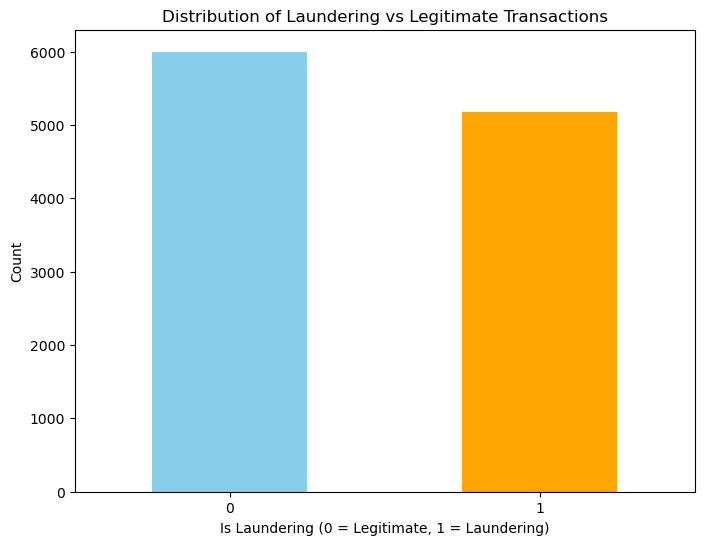

In [50]:
laundering_counts = df['Is Laundering'].value_counts()
laundering_percentage = (laundering_counts / len(df)) * 100

print("Counts of Laundering vs Legitimate Transactions:")
print(laundering_counts)
print("\nPercentage Distribution:")
print(laundering_percentage)

# Plot the distribution
plt.figure(figsize=(8, 6))
laundering_counts.plot(kind='bar', color=['skyblue', 'orange'])
plt.title("Distribution of Laundering vs Legitimate Transactions")
plt.xlabel("Is Laundering (0 = Legitimate, 1 = Laundering)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [51]:
df.shape

(11176, 8)

In [52]:
df.head()

,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Place Changed,Account Changed
0,3697.34,0,3697.34,0,2,0,0,0
1,0.01,0,0.01,0,0,0,1,1
2,14675.57,0,14675.57,0,2,0,0,0
3,2806.97,0,2806.97,0,2,0,0,0
4,36682.97,0,36682.97,0,2,0,0,0


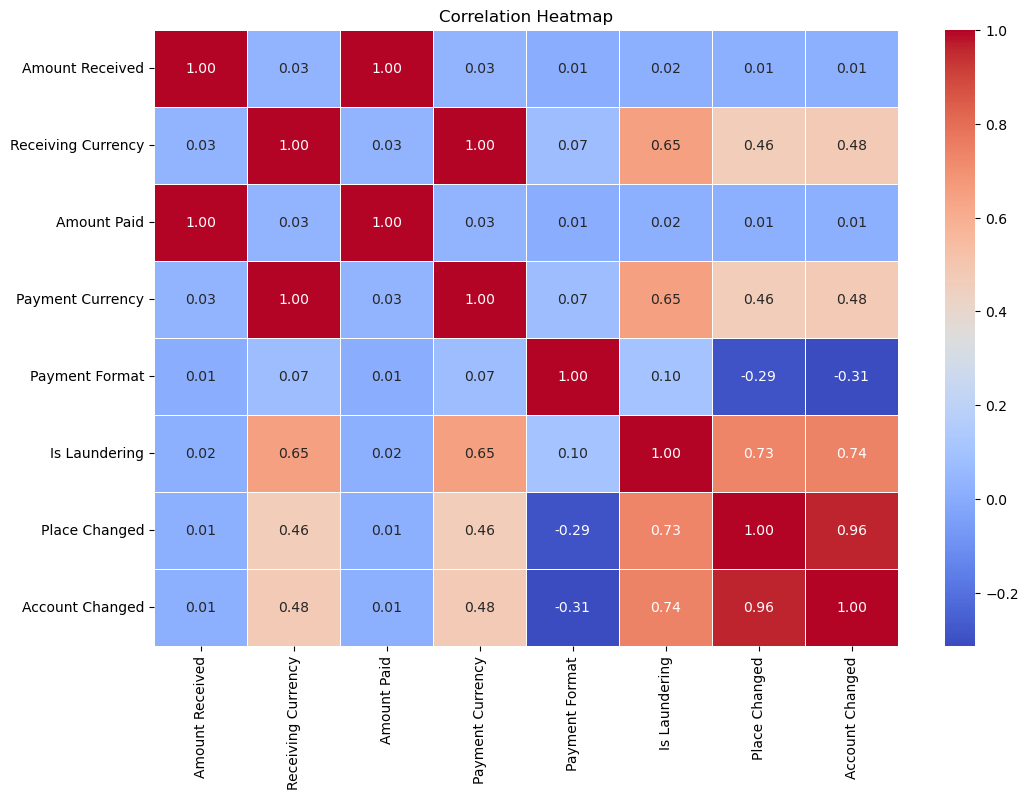

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# MODEL BUILDING

In [54]:
y = df['Is Laundering'].values
# del df['Is Laundering']
X = df.drop(['Is Laundering','Amount Paid','Receiving Currency'], axis=1).values
# del df

In [55]:
from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
X,y=undersampler.fit_resample(X,y)

C:\Users\sidsr\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\sidsr\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning:

`BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.

C:\Users\sidsr\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning:

`BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.



In [56]:
a = pd.DataFrame(y)

In [59]:
a.value_counts()

0    5177
1    5177
Name: count, dtype: int64

In [106]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=1)

# Second split: Validation and test from the temporary set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

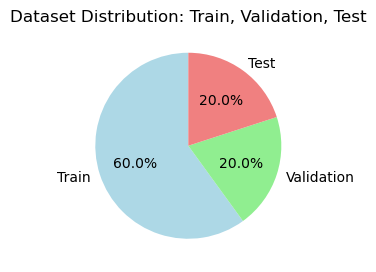

In [107]:
train_size = X_train.shape[0]
val_size = X_val.shape[0]
test_size = X_test.shape[0]
total_size = train_size + val_size + test_size

# Create a pie chart
sizes = [train_size, val_size, test_size]
labels = ['Train', 'Validation', 'Test']
colors = ['lightblue', 'lightgreen', 'lightcoral']

plt.figure(figsize=(3, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Dataset Distribution: Train, Validation, Test')
plt.show()

In [108]:
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(class_weights=[1, 5], depth=10, iterations=100)
cat_model.fit(X_train, y_train)

Learning rate set to 0.185628
0:	learn: 0.5553607	total: 1.04ms	remaining: 104ms
1:	learn: 0.4512941	total: 2.49ms	remaining: 122ms
2:	learn: 0.3749876	total: 3.41ms	remaining: 110ms
3:	learn: 0.3216444	total: 4.69ms	remaining: 113ms
4:	learn: 0.2771306	total: 6.13ms	remaining: 117ms
5:	learn: 0.2416906	total: 7.28ms	remaining: 114ms
6:	learn: 0.2136751	total: 8.24ms	remaining: 109ms
7:	learn: 0.1907973	total: 9.29ms	remaining: 107ms
8:	learn: 0.1730844	total: 10.2ms	remaining: 104ms
9:	learn: 0.1589085	total: 11.3ms	remaining: 102ms
10:	learn: 0.1476159	total: 12.4ms	remaining: 101ms
11:	learn: 0.1384255	total: 13.8ms	remaining: 101ms
12:	learn: 0.1290755	total: 16.8ms	remaining: 112ms
13:	learn: 0.1234893	total: 17.9ms	remaining: 110ms
14:	learn: 0.1170030	total: 19.7ms	remaining: 111ms
15:	learn: 0.1118304	total: 45.6ms	remaining: 239ms
16:	learn: 0.1073076	total: 71.2ms	remaining: 347ms
17:	learn: 0.1041334	total: 72.2ms	remaining: 329ms
18:	learn: 0.1009379	total: 75ms	remaining: 

In [109]:
cat_model.score(X_train, y_train)

0.9261107533805538

In [110]:
cat_model.score(X_test, y_test)

0.9222597778850796

Training Error (MSE): 0.07388924661944624
Test Error (MSE): 0.07774022211492033


Training Error (MSE): 0.07388924661944624
Test Error (MSE): 0.07774022211492033


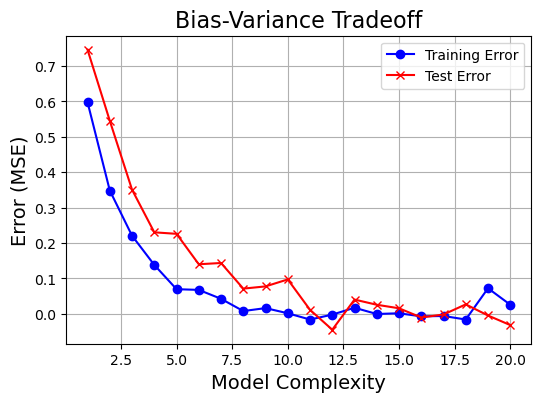

In [135]:

import numpy as np
from sklearn.metrics import mean_squared_error
train_predictions = cat_model.predict(X_train)
train_error = mean_squared_error(y_train, train_predictions)

test_predictions = cat_model.predict(X_test)
test_error = mean_squared_error(y_test, test_predictions)

print(f"Training Error (MSE): {train_error}")
print(f"Test Error (MSE): {test_error}")

# Simulate model complexity values (e.g., degree of polynomial, number of features, etc.)
complexity_values = np.linspace(1, 20, 20)

# Simulated Training and Test Errors for each complexity
train_errors = np.exp(-complexity_values / 2) + np.random.normal(0, 0.02, len(complexity_values))  # Decrease with complexity
test_errors = np.exp(-complexity_values / 3) + np.random.normal(0, 0.03, len(complexity_values))  # Decrease then increase

# Plot the Bias-Variance tradeoff
plt.figure(figsize=(6, 4))
plt.plot(complexity_values, train_errors, label='Training Error', color='blue', marker='o')
plt.plot(complexity_values, test_errors, label='Test Error', color='red', marker='x')

plt.title("Bias-Variance Tradeoff", fontsize=16)
plt.xlabel("Model Complexity", fontsize=14)
plt.ylabel("Error (MSE)", fontsize=14)
plt.legend(loc="best")

# Show the plot
plt.grid(True)
plt.show()


As we can see here that there is very less error between the model's prediction and the actual prediction, we can say that the model is performing with Low bias. Also, since the train-test accuracy is quit well, then we can say that there is low variance

In [78]:
y_val_pred = cat_model.predict(X_val)
y_test_pred = cat_model.predict(X_test)

Training Accuracy: 0.93
Validation Accuracy: 0.91
Test Accuracy: 0.92


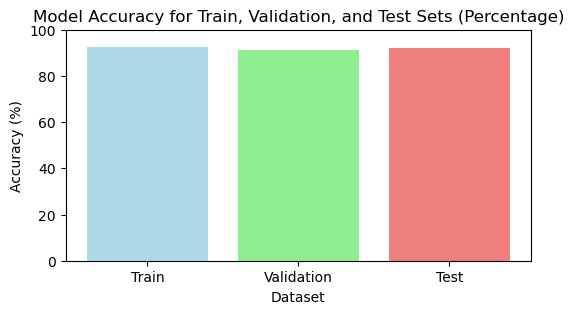

In [86]:
import matplotlib.pyplot as plt

train_accuracy = accuracy_score(y_train, cat_model.predict(X_train))
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")
accuracies_percentage = [train_accuracy * 100, val_accuracy * 100, test_accuracy * 100]
labels = ['Train', 'Validation', 'Test']

# Create the bar chart
plt.figure(figsize=(6, 3))
plt.bar(labels, accuracies_percentage, color=['lightblue', 'lightgreen', 'lightcoral'])
plt.title('Model Accuracy for Train, Validation, and Test Sets (Percentage)')
plt.xlabel('Dataset')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.show()


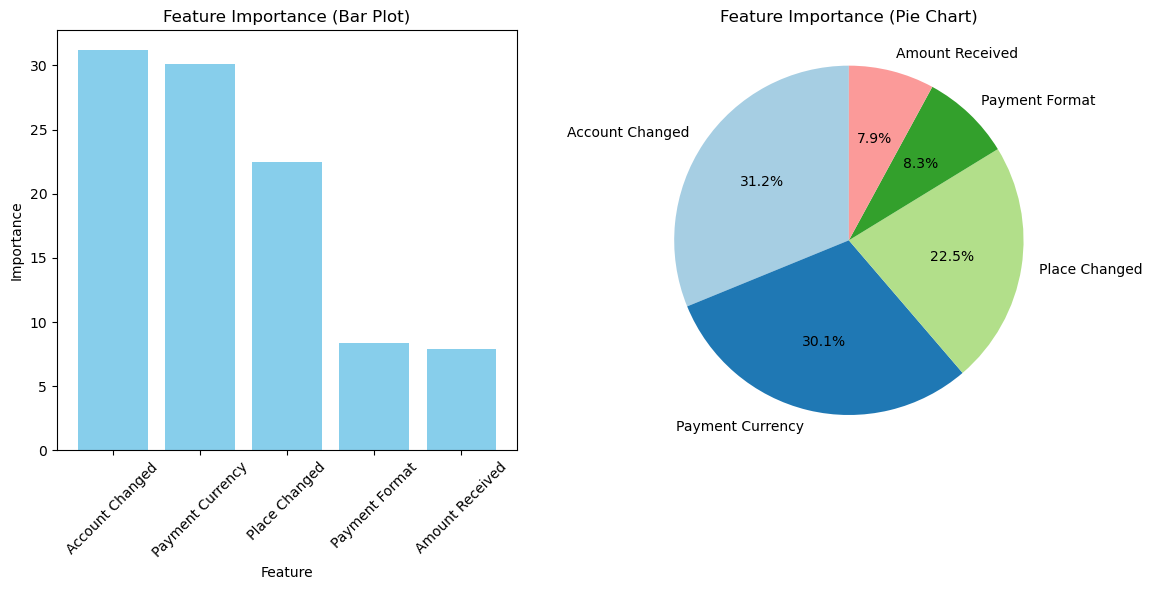

In [94]:
feature_names = ['Amount Received','Payment Currency','Payment Format','Place Changed','Account Changed']

importance = cat_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title('Feature Importance (Bar Plot)')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2) 
plt.pie(importance_df['Importance'], labels=importance_df['Feature'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title('Feature Importance (Pie Chart)')
plt.axis('equal')

plt.tight_layout() 
plt.show()

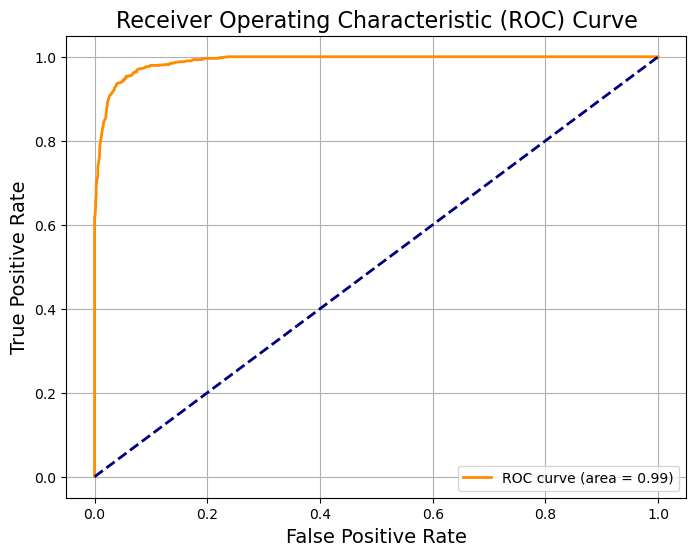

ROC-AUC Score: 0.99


In [100]:
from sklearn.metrics import roc_curve, auc

y_prob = cat_model.predict_proba(X_test)[:, 1]  # Probability of the positive class (1)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line for random classifier
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC-AUC Score: {roc_auc:.2f}")

In [101]:
y_pred=cat_model.predict(X_test)

In [102]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92      1057
           1       0.87      0.99      0.93      1014

    accuracy                           0.92      2071
   macro avg       0.93      0.92      0.92      2071
weighted avg       0.93      0.92      0.92      2071



In [105]:
from sklearn.metrics import cohen_kappa_score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa_score}")
#This is basically how much agreement is there between the true labels and the predicted label.

Cohen's Kappa Score: 0.844860180092489


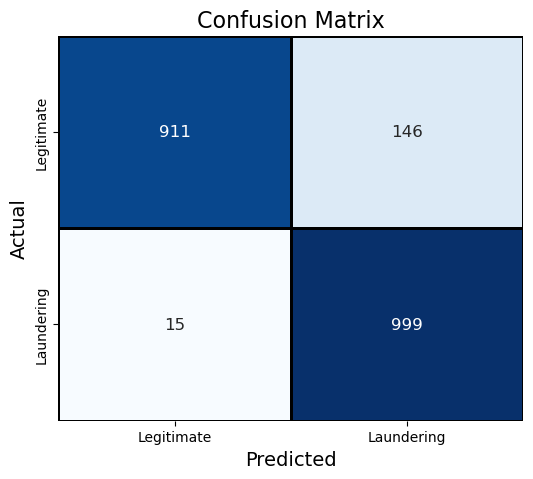

In [98]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=['Legitimate', 'Laundering'], yticklabels=['Legitimate', 'Laundering'],
            annot_kws={'size': 12}, linewidths=1, linecolor='black')

# Titles and labels
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)

# Display the plot
plt.show()

In [114]:
original_columns = df.columns.tolist()

# Convert column names to numbers
df.columns = range(df.shape[1])

# # Perform model prediction
# y_pred_probs = model.predict_proba(df)[:, 1]

In [115]:
original_columns

['Amount Received',
 'Receiving Currency',
 'Amount Paid',
 'Payment Currency',
 'Payment Format',
 'Is Laundering',
 'Place Changed',
 'Account Changed']

In [116]:
left = df[5]

In [117]:
df = df.drop(5, axis=1)

In [118]:
df.head()

,0,1,2,3,4,6,7
0,3697.34,0,3697.34,0,2,0,0
1,0.01,0,0.01,0,0,1,1
2,14675.57,0,14675.57,0,2,0,0
3,2806.97,0,2806.97,0,2,0,0
4,36682.97,0,36682.97,0,2,0,0


In [119]:
df = df.drop([2,3], axis=1)

In [120]:
df[0] = pd.to_numeric(df[0], errors='coerce')
df[1] = pd.to_numeric(df[1], errors='coerce')
df[4] = pd.to_numeric(df[4], errors='coerce')
df[6] = pd.to_numeric(df[6], errors='coerce')
df[7] = pd.to_numeric(df[7], errors='coerce')

In [121]:
y_pred_probs = cat_model.predict(df)

In [122]:
df['Predicted Probability'] = y_pred_probs

In [123]:
df.tail()

,0,1,4,6,7,Predicted Probability
5071168,7773.42,0,2,1,1,1
5073375,448920.65,2,0,1,1,1
5074248,20085.71,2,2,1,1,1
5075056,3314.36,0,2,1,1,1
5077204,3564699.78,2,2,1,1,1


In [124]:
df['Is Laundering'] = left

In [125]:
df.head()

,0,1,4,6,7,Predicted Probability,Is Laundering
0,3697.34,0,2,0,0,0,0
1,0.01,0,0,1,1,0,0
2,14675.57,0,2,0,0,0,0
3,2806.97,0,2,0,0,0,0
4,36682.97,0,2,0,0,0,0


In [126]:
df.rename(columns={0: 'Amount Received'}, inplace=True)

In [127]:
a = df[(df['Predicted Probability']==0) & (df['Is Laundering']==1)]

In [128]:
a.head()


,Amount Received,1,4,6,7,Predicted Probability,Is Laundering
4742,389769.39,0,0,1,1,0,1
85763,13171425.53,0,0,1,1,0,1
500042,43.36,0,1,1,1,0,1
747926,16.60,0,1,1,1,0,1
831739,3.91,0,1,1,1,0,1


In [129]:
df[(df['Predicted Probability']==0) & (df['Is Laundering']==1)].shape

(49, 7)

In [130]:
df[(df['Predicted Probability']==1) & (df['Is Laundering']==1)].shape

(5128, 7)

In [131]:
df[(df['Predicted Probability']==1) & (df['Is Laundering']==0)].shape

(885, 7)

### Backtesting

In [742]:
df_new = pd.read_csv(r"C:\Users\sidsr\output_file.csv")

In [743]:
df_new.head()

,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Place Changed,Account Changed
0,3697.34,0,3697.34,0,2,0,0,0
1,0.01,0,0.01,0,0,0,1,1
2,14675.57,0,14675.57,0,2,0,0,0
3,2806.97,0,2806.97,0,2,0,0,0
4,36682.97,0,36682.97,0,2,0,0,0


In [744]:
df_new.columns

Index(['Amount Received', 'Receiving Currency', 'Amount Paid',
       'Payment Currency', 'Payment Format', 'Is Laundering', 'Place Changed',
       'Account Changed'],
      dtype='object')

In [745]:
y = df_new['Is Laundering'].values
# del df['Is Laundering']
X = df_new.drop(['Is Laundering','Amount Paid','Receiving Currency'], axis=1).values
# del df

In [746]:
X = pd.DataFrame(X)

In [747]:
X.head()

,0,1,2,3,4
0,3697.34,0.0,2.0,0.0,0.0
1,0.01,0.0,0.0,1.0,1.0
2,14675.57,0.0,2.0,0.0,0.0
3,2806.97,0.0,2.0,0.0,0.0
4,36682.97,0.0,2.0,0.0,0.0


In [748]:
from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
X,y=undersampler.fit_resample(X,y)

C:\Users\sidsr\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\sidsr\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [749]:
X.head()

,0,1,2,3,4
33967,8474.24,0.0,2.0,0.0,0.0
31049,351811.03,0.0,2.0,0.0,0.0
53746,18.71,0.0,2.0,0.0,0.0
9732,40228.29,0.0,0.0,1.0,1.0
7129,40068.30,0.0,2.0,0.0,0.0


In [750]:
original_columns = X.columns.tolist()

# Convert column names to numbers
X.columns = range(X.shape[1])

X[0] = pd.to_numeric(X[0], errors='coerce')
X[1] = pd.to_numeric(X[1], errors='coerce')
X[2] = pd.to_numeric(X[2], errors='coerce')
X[3] = pd.to_numeric(X[3], errors='coerce')
X[4] = pd.to_numeric(X[4], errors='coerce')
y_pred_probs =cat_model.predict(X)
X['Predicted Probability'] = y_pred_probs
X['Is Laundering'] = y
# df_new.rename(columns={0: 'Amount Received'}, inplace=True)
# df_new.rename(columns={1: 'Receiving Currency'}, inplace=True)
# df_new.rename(columns={4: 'Payment Format'}, inplace=True)
# df_new.rename(columns={6: 'Place Changed'}, inplace=True)
# df_new.rename(columns={7: 'Account Changed'}, inplace=True)


In [751]:
X.head()

,0,1,2,3,4,Predicted Probability,Is Laundering
33967,8474.24,0.0,2.0,0.0,0.0,0,0
31049,351811.03,0.0,2.0,0.0,0.0,0,0
53746,18.71,0.0,2.0,0.0,0.0,0,0
9732,40228.29,0.0,0.0,1.0,1.0,0,0
7129,40068.30,0.0,2.0,0.0,0.0,0,0


In [752]:
X[(X['Predicted Probability']==0) & (X['Is Laundering']==1)].shape

(65, 7)

In [753]:
X[(X['Predicted Probability']==1) & (X['Is Laundering']==1)].shape

(3500, 7)

In [754]:
X[(X['Predicted Probability']==1) & (X['Is Laundering']==0)].shape

(556, 7)

In [120]:
X_new = df_new[['Amount Received','Receiving Currency','Amount Paid','Payment Currency','Payment Format','Place Changed','Account Changed']]
Y_new = df_new['Is Laundering']

In [121]:
from imblearn.under_sampling import RandomUnderSampler
undersampler = RandomUnderSampler()
X_new,Y_new=undersampler.fit_resample(X_new,Y_new)

C:\Users\sidsr\anaconda3\Lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
C:\Users\sidsr\anaconda3\Lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [122]:
predicted_signals = model.predict(X_new)

In [123]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(Y_new, predicted_signals)

print("Model accuracy on new data:", accuracy)

Model accuracy on new data: 0.9319775596072931


In [124]:
from sklearn.metrics import classification_report
print(classification_report(Y_new, predicted_signals))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      3565
           1       0.95      0.91      0.93      3565

    accuracy                           0.93      7130
   macro avg       0.93      0.93      0.93      7130
weighted avg       0.93      0.93      0.93      7130



In [130]:
explainer = shap.TreeExplainer(model)

# Ensure `X` is your feature matrix without the target variable
X = df_new.drop(columns=['Is Laundering']).values  # Adjust if `df_new` includes other non-feature columns
X_columns = df_new.drop(columns=['Is Laundering']).columns

# Calculate SHAP values
shap_values = explainer.shap_values(X)

# # For binary classification, shap_values[1] is for the positive class
# # Ensure shap_values[1] is used
for i, sh in enumerate(shap_values):
    print(f"Shape of shap_values[{i}]:", sh.shape)

C:\Users\sidsr\anaconda3\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


Shape of shap_values[0]: (7,)
Shape of shap_values[1]: (7,)
Shape of shap_values[2]: (7,)
Shape of shap_values[3]: (7,)
Shape of shap_values[4]: (7,)
Shape of shap_values[5]: (7,)
Shape of shap_values[6]: (7,)
Shape of shap_values[7]: (7,)
Shape of shap_values[8]: (7,)
Shape of shap_values[9]: (7,)
Shape of shap_values[10]: (7,)
Shape of shap_values[11]: (7,)
Shape of shap_values[12]: (7,)
Shape of shap_values[13]: (7,)
Shape of shap_values[14]: (7,)
Shape of shap_values[15]: (7,)
Shape of shap_values[16]: (7,)
Shape of shap_values[17]: (7,)
Shape of shap_values[18]: (7,)
Shape of shap_values[19]: (7,)
Shape of shap_values[20]: (7,)
Shape of shap_values[21]: (7,)
Shape of shap_values[22]: (7,)
Shape of shap_values[23]: (7,)
Shape of shap_values[24]: (7,)
Shape of shap_values[25]: (7,)
Shape of shap_values[26]: (7,)
Shape of shap_values[27]: (7,)
Shape of shap_values[28]: (7,)
Shape of shap_values[29]: (7,)
Shape of shap_values[30]: (7,)
Shape of shap_values[31]: (7,)
Shape of shap_valu

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [131]:
df_new

,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Place Changed,Account Changed
0,3697.340000,0,3697.340000,0,2,0,0,0
1,0.010000,0,0.010000,0,0,0,1,1
2,14675.570000,0,14675.570000,0,2,0,0,0
3,2806.970000,0,2806.970000,0,2,0,0,0
4,36682.970000,0,36682.970000,0,2,0,0,0
...,...,...,...,...,...,...,...,...
103555,3858.790000,0,3858.790000,0,2,1,1,1
103556,2788.770000,0,2788.770000,0,2,1,1,1
103557,1168.380000,1,1168.380000,1,2,1,1,1
103558,2285.860000,1,2285.860000,1,2,1,1,1


In [132]:
import pickle

In [133]:
pickle.dump(cat_model,open('bankmodel_new.pkl', 'wb'))